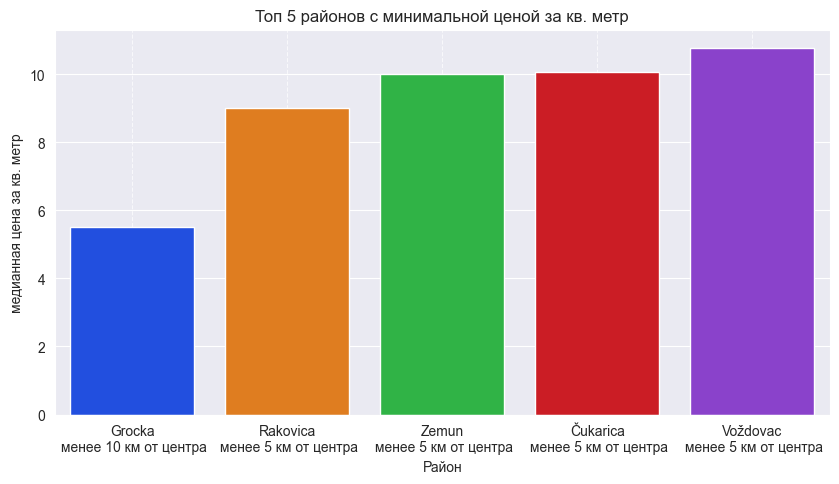

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

df = pd.read_csv('apartments.csv')


def transform_distance(val):
    if pd.isna(val):
        return None
    match = re.search(r'\d+', str(val))
    return float(match.group()) if match else None

df['distance']= df['distanceCenterArray'].apply(transform_distance)


cheap = (df.groupby('municipality').agg(pricePerSize=('pricePerSize', 'median'), distance=('distance', 'median')).sort_values(['pricePerSize', 'distance']).head(5).reset_index())


plt.figure(figsize = (10,5))
sns.barplot(x = 'municipality', y = 'pricePerSize', data = cheap, hue = 'municipality', palette='bright')
labels = [f"{row['municipality']}\n менее {row['distance']:.0f} км от центра" for _, row in cheap.iterrows()]
plt.xticks(range(len(cheap)), labels)
plt.title('Топ 5 районов с минимальной ценой за кв. метр')
plt.xlabel(f'Район')
plt.ylabel('медианная цена за кв. метр')
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()